## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Evaluation BertMorphTaggerHomonym50**](#hindamine_homonyms_50)
3. [**Results BertMorphTaggerHomonym50**](#tulemused_homonyms_50)
4. [**Results BertMorphTaggerHomonym50 testset**](#tulemused_homonyms_50_test)

[end](#end)


### Conclusive evaluation results for the model

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

#### Homonyms full set

| Model                                           | Accuracy | Precision | Recall | F1-score |
| ----------------------------------------------- | -------: | --------: | -----: | -------: |
| BertMorphTaggerV2Homonym50                      |   98.05% |    98.08% | 98.05% |   98.05% |
| BertMorphTaggerV2Homonym50 (lenient)            |   98.05% |    98.08% | 98.05% |   98.05% |
| BertMorphTaggerV2Homonym50 (lenient, no others) |   98.06% |    98.08% | 98.06% |   98.06% |

Predictions outside the set of possible labels: **1/7886 (0.01%)**

#### Homonyms test set

| Model                                           | Accuracy | Precision | Recall | F1-score |
| ----------------------------------------------- | -------: | --------: | -----: | -------: |
| BertMorphTaggerV2Homonym50                      |   97.91% |    97.95% | 97.91% |   97.91% |
| BertMorphTaggerV2Homonym50 (lenient)            |   97.91% |    97.95% | 97.91% |   97.91% |
| BertMorphTaggerV2Homonym50 (lenient, no others) |   97.91% |    97.95% | 97.91% |   97.91% |

Predictions outside the set of possible labels: **0/3643 (0.00%)**


### Imports


In [1]:
print("Test")

Test


In [2]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [ ]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [ ]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


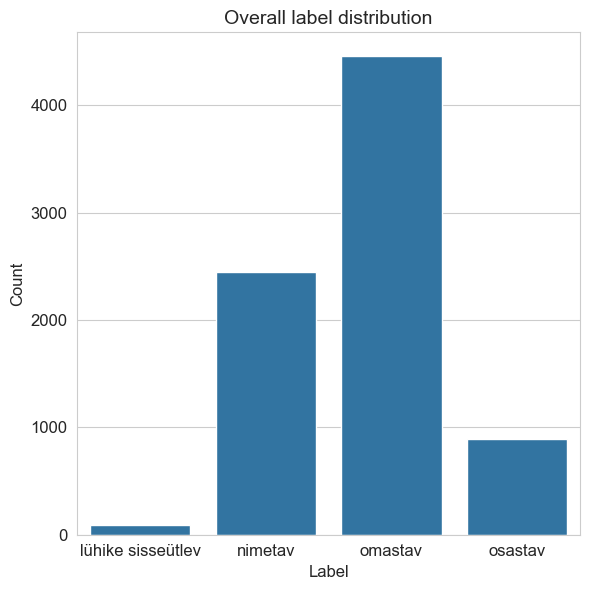

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


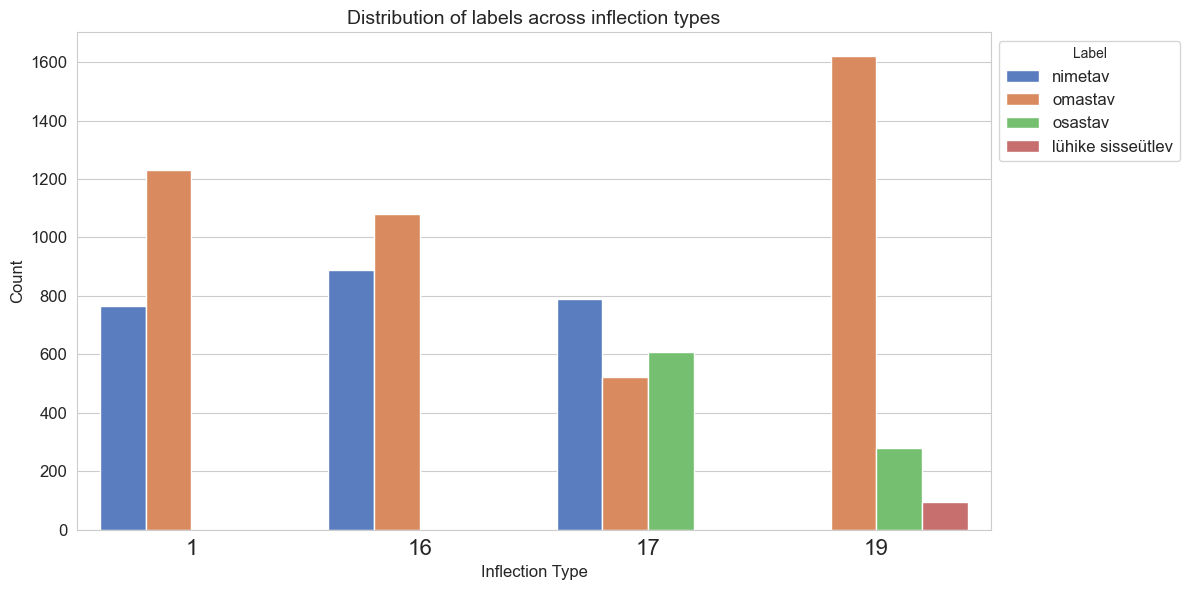

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='hindamine_homonyms_50'></a>


### Evaluation BertMorphTaggerHomonym_50


In [3]:
# Define model to use for annotation
model_path = "../models/NER_mudel_v2_homonym_50/"
model_name = "BertMorphTaggerV2Homonym50"
df_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Bert_morph_V2_homonym_50.csv"
)
df_test_output_csv_path = str(
    HOMONYMS_DIRS["annotations"]
    / "homonyms_annotations_test_Bert_morph_V2_homonym_50.csv"
)

In [45]:
test_df = pd.read_parquet(HOMONYMS_DIRS["processed"] / "homonyms_test_50.parquet")

In [ ]:
display(overall_df.head())
display(test_df.head())

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


,sentence_id,words,form,pos,labels,infl_type,source
0,22,Kakskümmend,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,22,aastat,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,22,tagasi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,22,töötasin,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,22,teadurina,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [ ]:
print(len(test_df[test_df["labels"] != "-"]), "sentences")

3943 sentences


In [ ]:
# Gather homonym rows present in the test set
test_homonym_rows = test_df[test_df["labels"] != "-"]
overall_df["sentence_id"] = overall_df.index
# Gather corresponding rows from the overall dataframe
# Group sentence_id and source to ensure we get the correct sentences
test_sentence_groups = (
    test_homonym_rows.groupby(["sentence_id", "source"])
    .size()
    .reset_index()[["sentence_id", "source"]]
)
test_overall_rows = pd.merge(
    test_sentence_groups,
    overall_df,
    on=["sentence_id", "source"],
    how="inner",
)
print(
    f"Found {len(test_overall_rows)} matching rows in overall dataframe for the test set."
)

Found 3643 matching rows in overall dataframe for the test set.


In [ ]:
display(test_overall_rows.head())

,sentence_id,source,num,inflection_type,sentence,word,word_span,label
0,22,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json,1,1,Kakskümmend aastat tagasi töötasin teadurina Raadio Vaba Euroopa Instituudis.,Euroopa,"[57, 64]","(sg g,)"
1,25,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json,1,1,"Seminarile on eelkõige oodatud kohalike omavalitsuste ja prefektuuride profülaktikatalituste juhid, ütles ETAle Tartu naabrusvalve projektijuht Peeter Rehemaa.",Tartu,"[112, 117]","(sg g,)"
2,26,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json,1,1,"USA ja Kanada uuringute instituudi direktor Sergei Rogov lisas, et kõigil Ida-Euroopa riikidel tuleb arvestada nüüd NATO 6+1 vormiga ning eilsest alates on Venemaal Euroopa julgeolekut puudutavates küsimustes vetoõigus.",Euroopa,"[165, 172]","(sg g,)"
3,27,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json,1,1,"; Kui hakkavad kehtima ühtsed lemmikloomapassid, mis karmistavad loomade tervisenõudeid, siis on võimalik ka Eestis elavate loomadega kõigisse Euroopa riikidesse reisida.",Euroopa,"[143, 150]","(sg g,)"
4,31,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json,1,1,"Rahu tänavast varastati vana Žiguli Pühapäeva hommikul kell seitse teatati politseisse, et Rahu tänava maja eest on varastatud sinine 1972. aasta Žiguli 01 (026 TAG).",aasta,"[140, 145]","(sg g,)"


In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_output_csv_path,
    progress_desc="Evaluating BertMorphTaggerHomonym_50",
)

Evaluating BertMorphTaggerHomonym_50: 100%|██████████| 7886/7886 [07:36<00:00, 17.27it/s]


In [ ]:
display(results_df.head())

,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",sg n,sg n,False,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",sg n,sg n,False,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",sg n,sg n,False,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",sg n,sg n,False,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",sg g,sg g,False,1,1


In [ ]:
# Filter results_df to only include examples that are in the test set
results_test_df = results_df[results_df.index.isin(test_df.index)]

results_test_df.to_csv(df_test_output_csv_path, index=False)

In [ ]:
display(results_test_df.head())

,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
0,Kakskümmend aastat tagasi töötasin teadurina Raadio Vaba Euroopa Instituudis.,Euroopa,"(57, 64)",sg g,sg g,False,1,1
1,"Seminarile on eelkõige oodatud kohalike omavalitsuste ja prefektuuride profülaktikatalituste juhid, ütles ETAle Tartu naabrusvalve projektijuht Peeter Rehemaa.",Tartu,"(112, 117)",sg g,sg g,False,1,1
2,"USA ja Kanada uuringute instituudi direktor Sergei Rogov lisas, et kõigil Ida-Euroopa riikidel tuleb arvestada nüüd NATO 6+1 vormiga ning eilsest alates on Venemaal Euroopa julgeolekut puudutavates küsimustes vetoõigus.",Euroopa,"(165, 172)",sg g,sg g,False,1,1
3,"; Kui hakkavad kehtima ühtsed lemmikloomapassid, mis karmistavad loomade tervisenõudeid, siis on võimalik ka Eestis elavate loomadega kõigisse Euroopa riikidesse reisida.",Euroopa,"(143, 150)",sg g,sg g,False,1,1
4,"Rahu tänavast varastati vana Žiguli Pühapäeva hommikul kell seitse teatati politseisse, et Rahu tänava maja eest on varastatud sinine 1972. aasta Žiguli 01 (026 TAG).",aasta,"(140, 145)",sg g,sg g,False,1,1


<a id='tulemused_homonyms_50'></a>


### Results BertMorphTaggerHomonyms50


In [4]:
# Load results dataframe
results_df = pd.read_csv(
    df_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

BertMorphTaggerV2Homonym50 results:
Overall results
Accuracy:  98.05%
Precision: 98.08%
Recall:    98.05%
F1-score:  98.05%

BertMorphTaggerV2Homonym50 results (lenient):
Overall results
Accuracy:  98.05%
Precision: 98.08%
Recall:    98.05%
F1-score:  98.05%

BertMorphTaggerV2Homonym50 results (lenient, excluding 'other'):
Overall results
Accuracy:  98.06%
Precision: 98.08%
Recall:    98.06%
F1-score:  98.06%

Number of "other" cases: 1 out of 7886 (0.01%)


In [5]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2Homonym50 classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.98      0.97      0.97        94
           o       0.00      0.00      0.00         0
        sg g       0.98      0.99      0.99      4457
        sg n       0.99      0.96      0.98      2445
        sg p       0.94      0.96      0.95       890

    accuracy                           0.98      7886
   macro avg       0.78      0.78      0.78      7886
weighted avg       0.98      0.98      0.98      7886



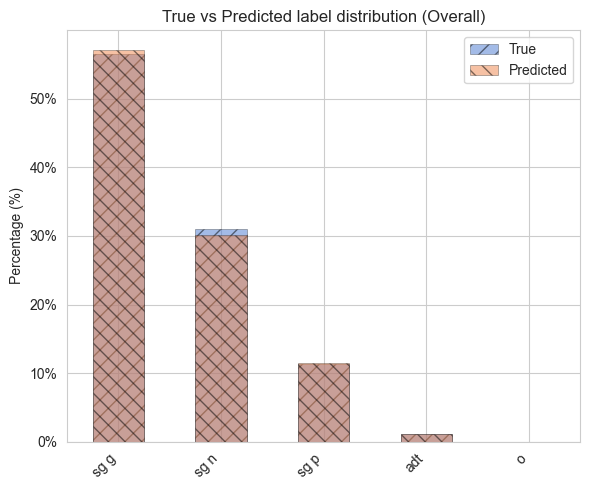

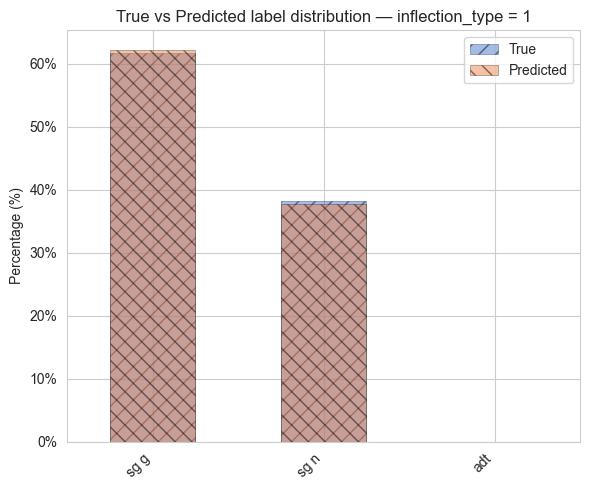

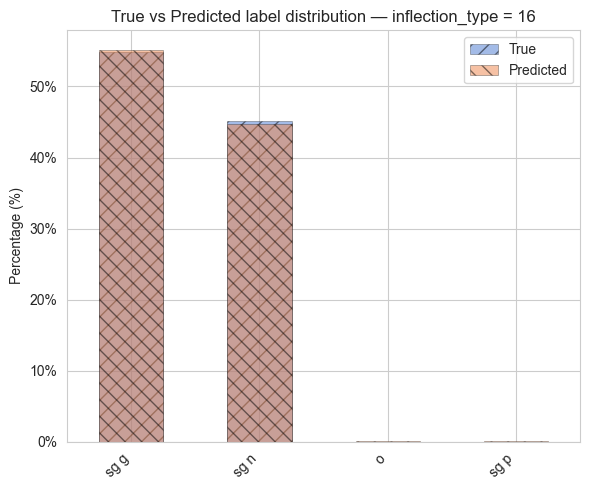

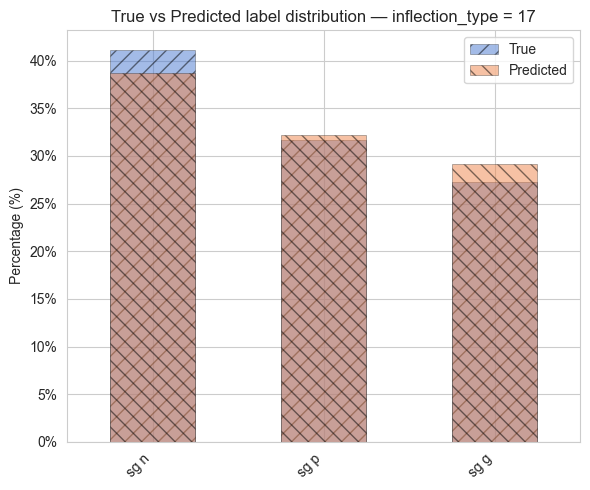

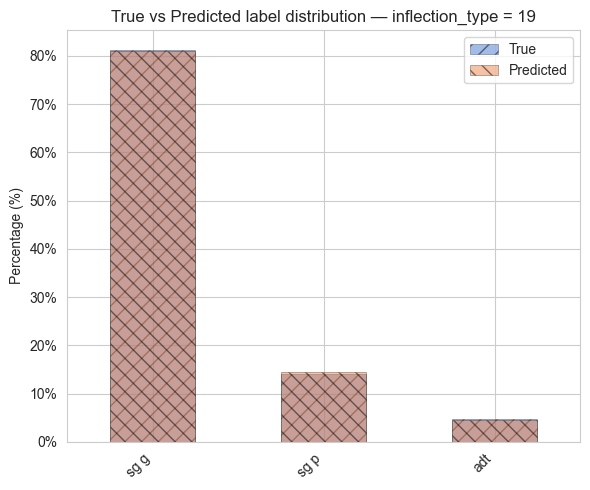

In [6]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

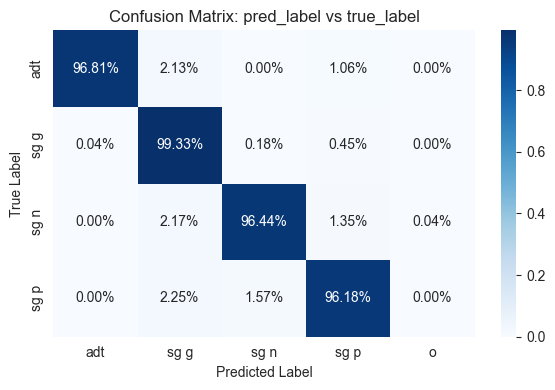

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    o      1       0.01              True              0
Sum of true labels count: 7886


In [7]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

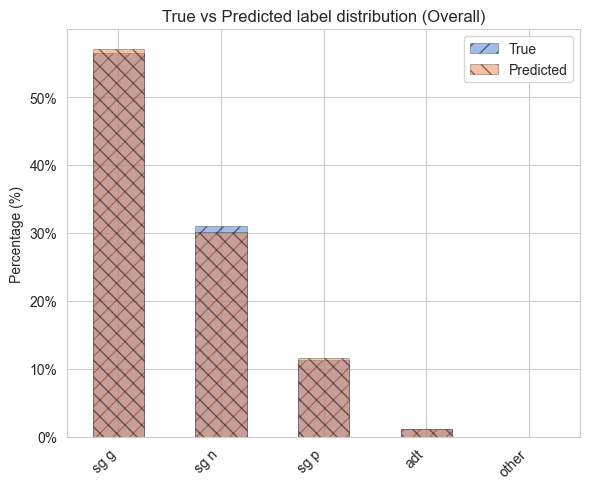

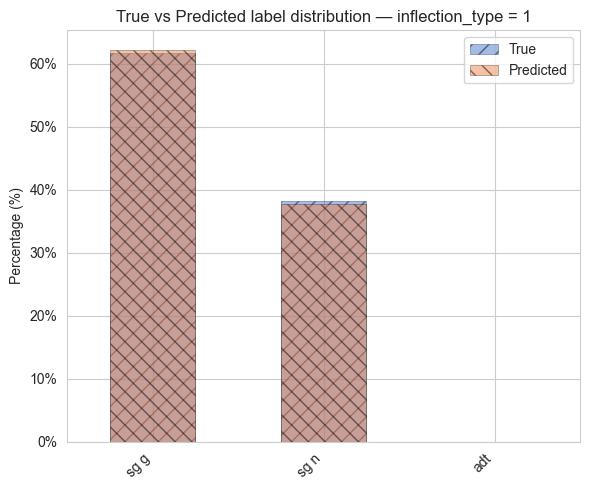

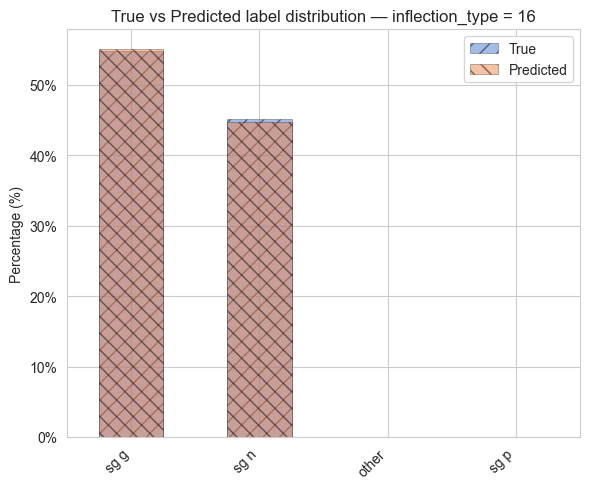

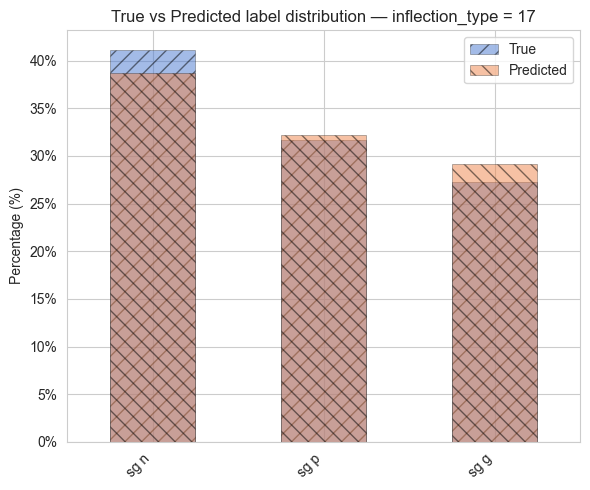

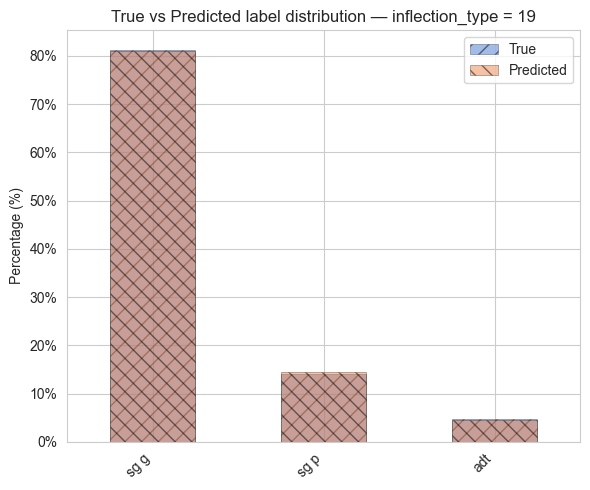

In [8]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

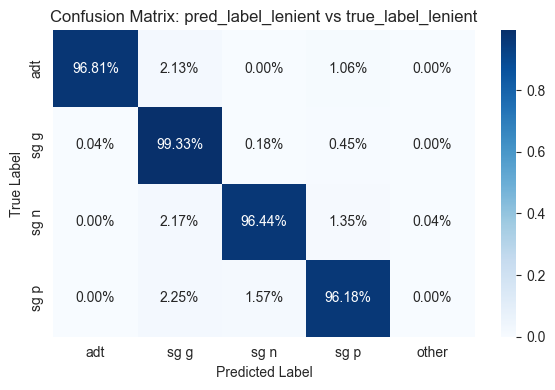

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      1       0.01              True              0
Sum of true labels count: 7886


In [9]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

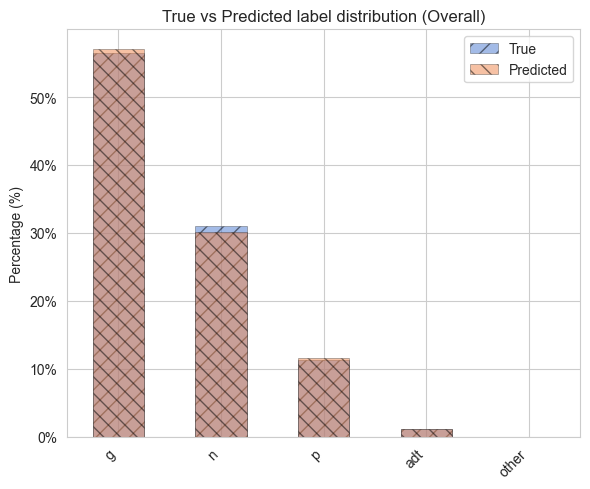

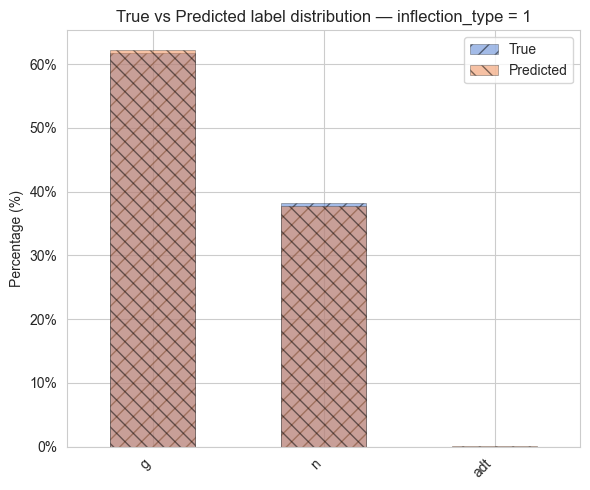

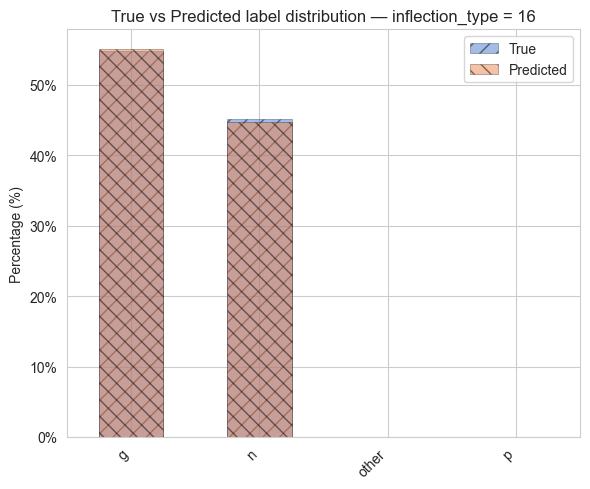

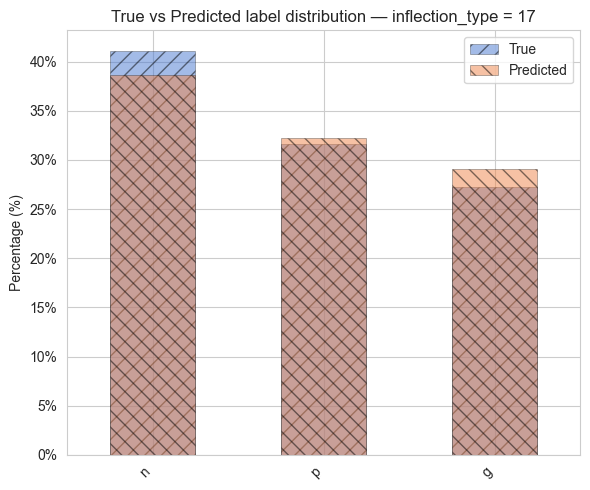

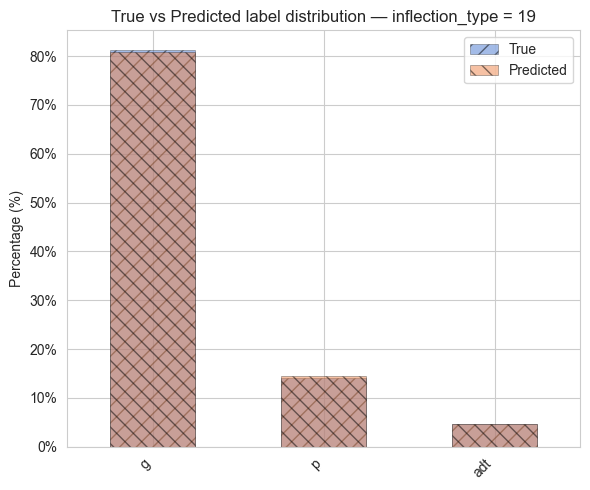

In [10]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

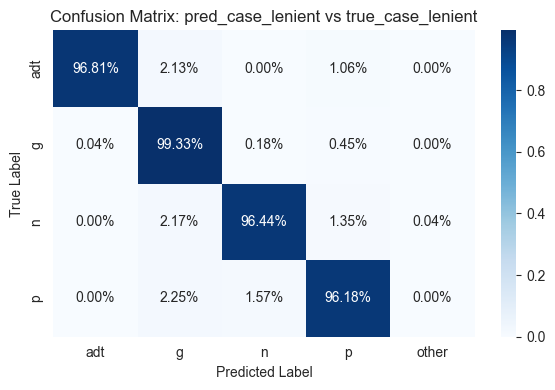

Confusion Matrix: pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      1       0.01              True              0
Sum of true labels count: 7886


In [11]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

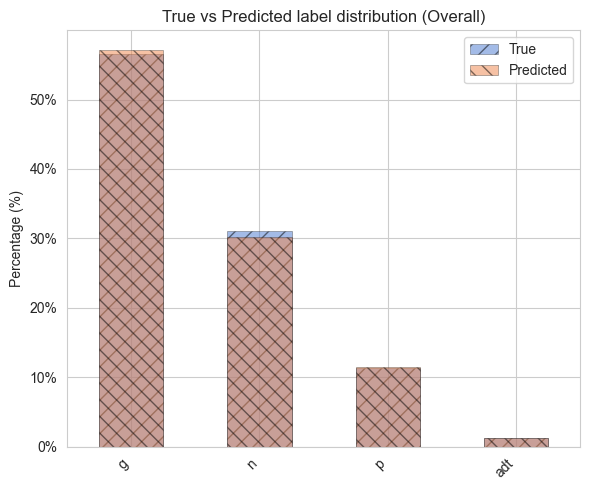

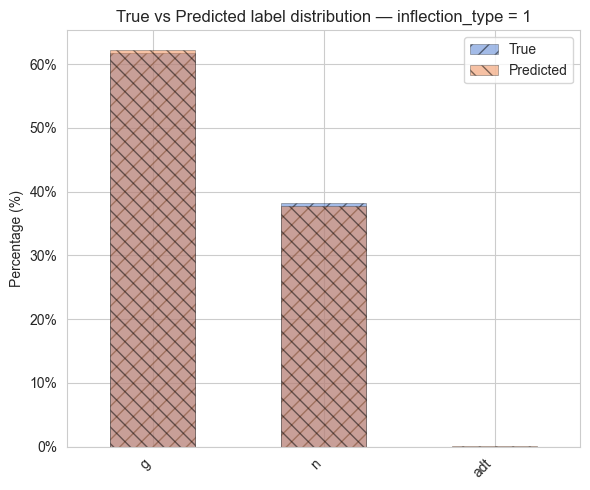

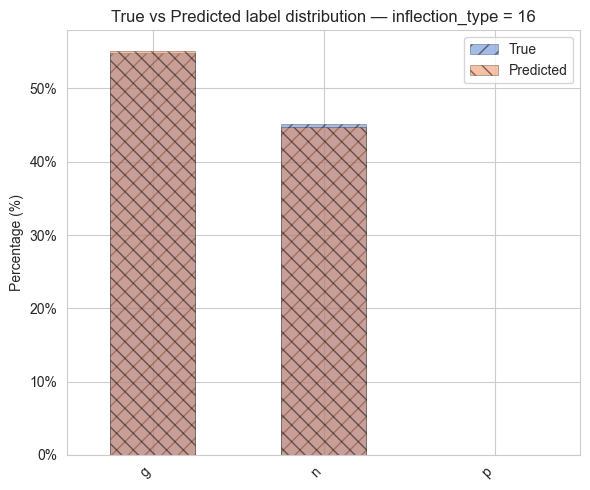

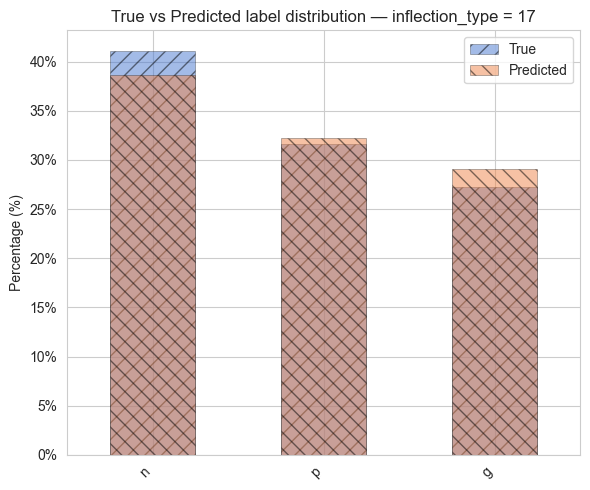

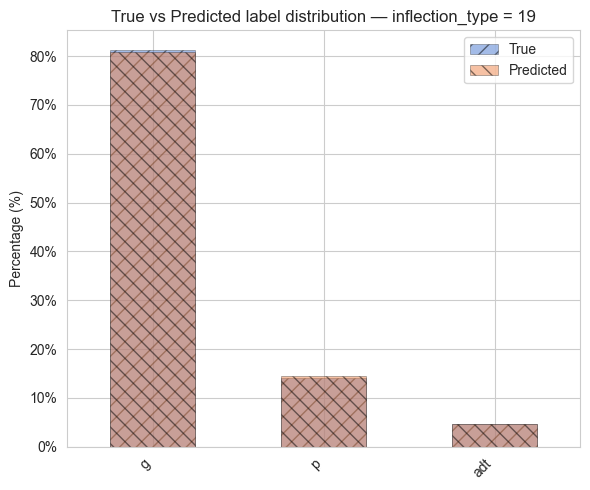

In [12]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

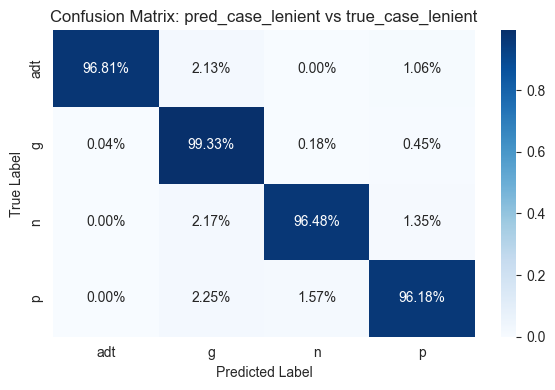

In [13]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [14]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2Homonym50 results per inflection type:
inflection_type=1
Accuracy:  99.05%
Precision: 99.10%
Recall:    99.05%
F1-score:  99.07%
inflection_type=16
Accuracy:  99.39%
Precision: 99.49%
Recall:    99.39%
F1-score:  99.44%
inflection_type=17
Accuracy:  94.59%
Precision: 94.74%
Recall:    94.59%
F1-score:  94.60%
inflection_type=19
Accuracy:  99.05%
Precision: 99.06%
Recall:    99.05%
F1-score:  99.05%


In [15]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2Homonym50 classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
        sg g       0.99      1.00      0.99      1232
        sg n       0.99      0.98      0.99       764

    accuracy                           0.99      1996
   macro avg       0.66      0.66      0.66      1996
weighted avg       0.99      0.99      0.99      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

           o       0.00      0.00      0.00         0
        sg g       0.99      1.00      1.00      1080
        sg n       1.00      0.99      0.99       890
        sg p       0.00      0.00      0.00         0

    accuracy                           0.99      1970
   macro avg       0.50      0.50      0.50      1970
weighted avg       0.99      0.99      0.99      1970

inflection_type=17 - Classif

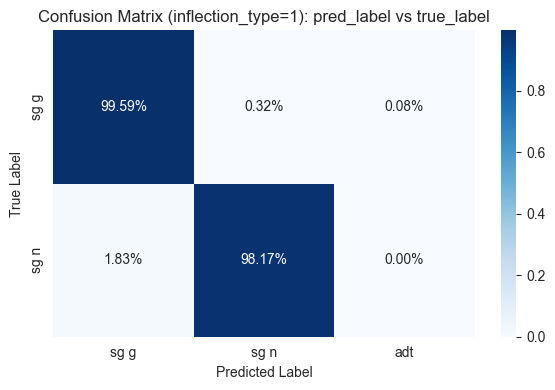

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1996


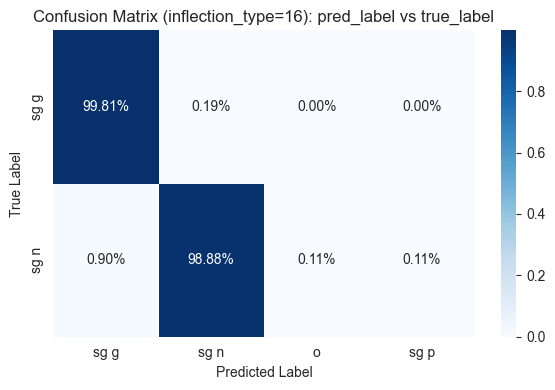

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    o      1       0.05              True              0
1                 sg p      1       0.05              True              0
Sum of true labels count: 1970


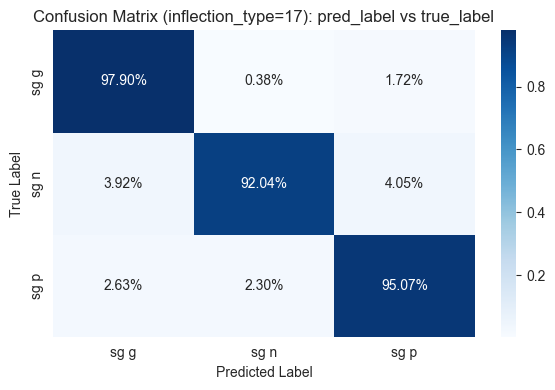

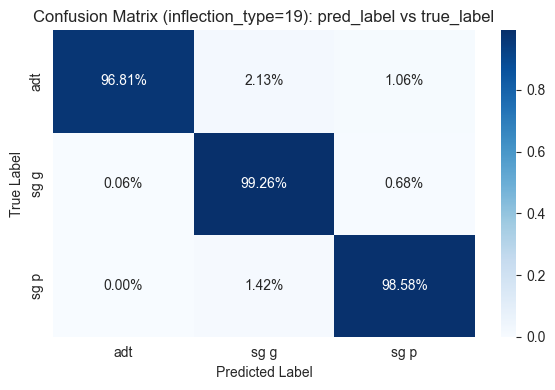

In [16]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

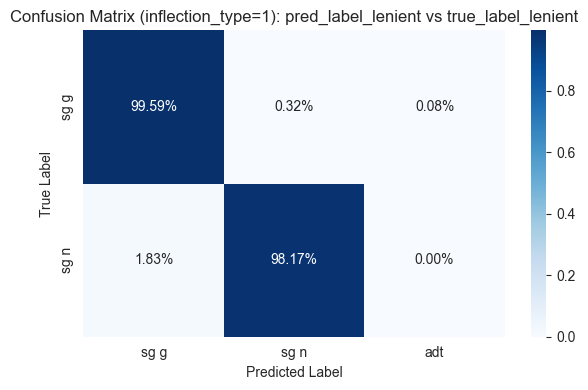

Confusion Matrix (inflection_type=1): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1996


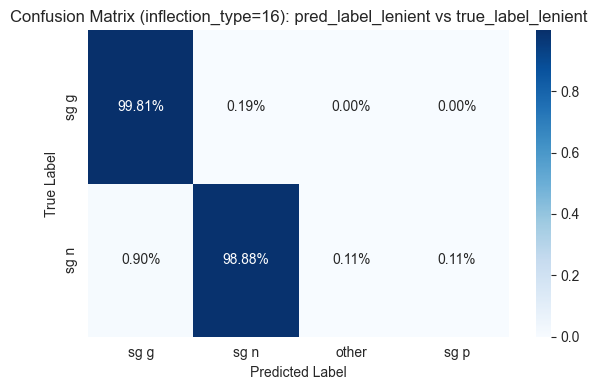

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      1       0.05              True              0
1                 sg p      1       0.05              True              0
Sum of true labels count: 1970


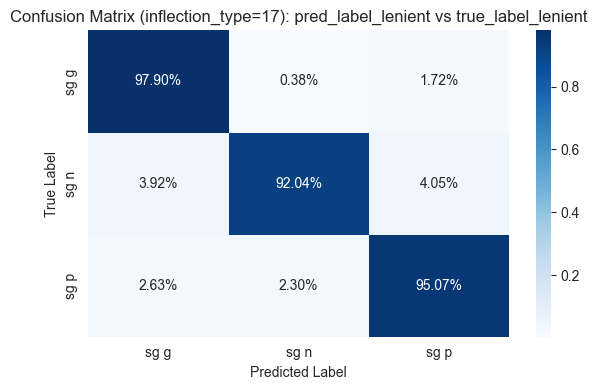

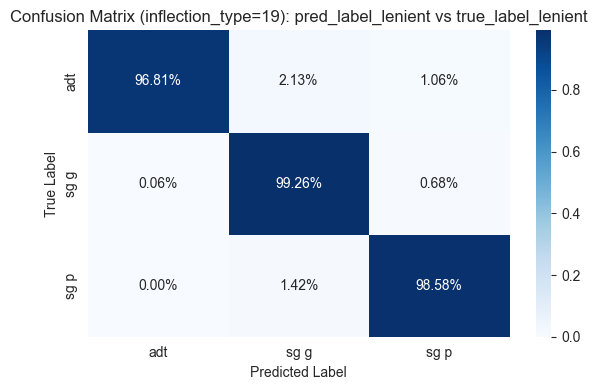

In [17]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

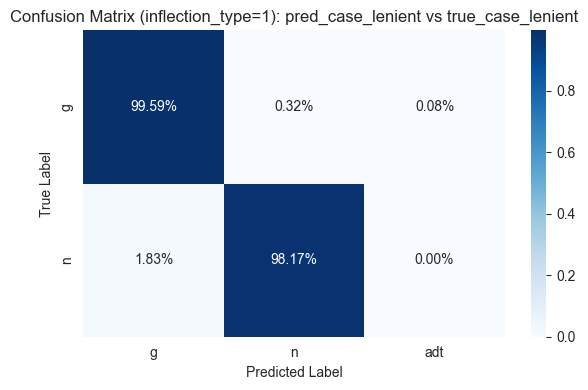

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1996


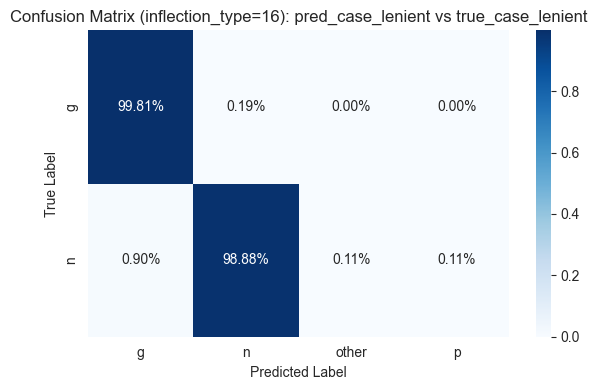

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      1       0.05              True              0
1                    p      1       0.05              True              0
Sum of true labels count: 1970


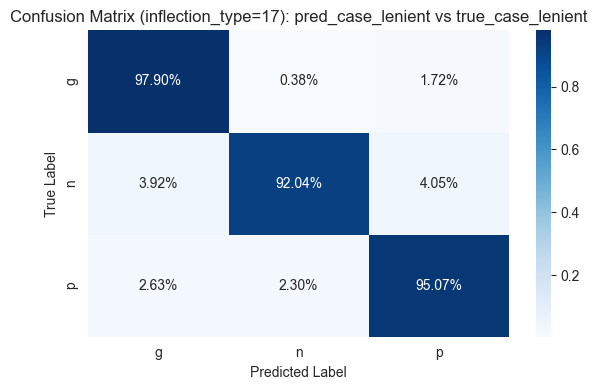

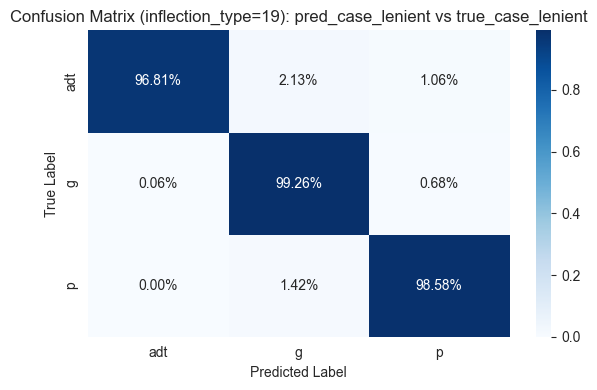

In [18]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

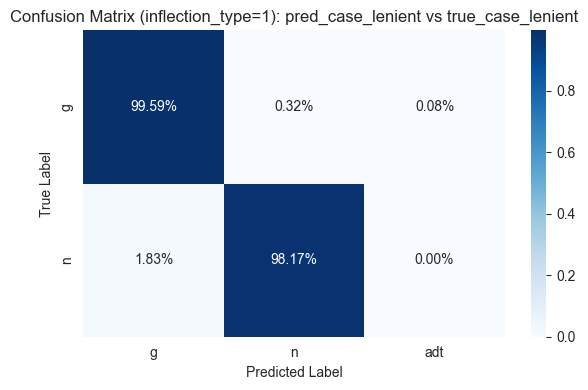

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
Sum of true labels count: 1996


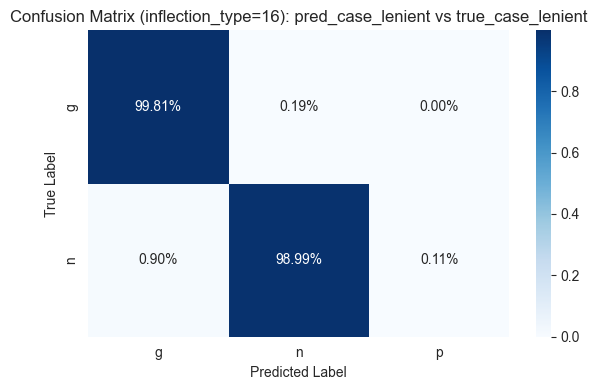

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p      1       0.05              True              0
Sum of true labels count: 1969


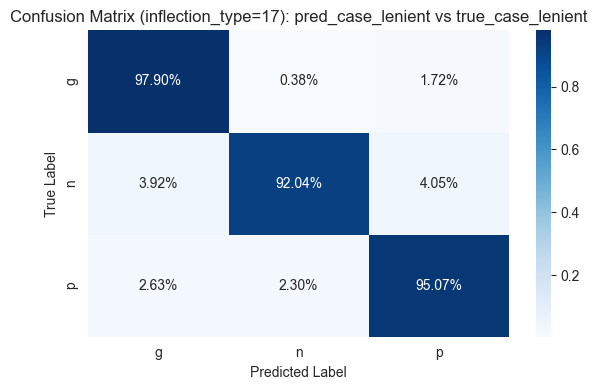

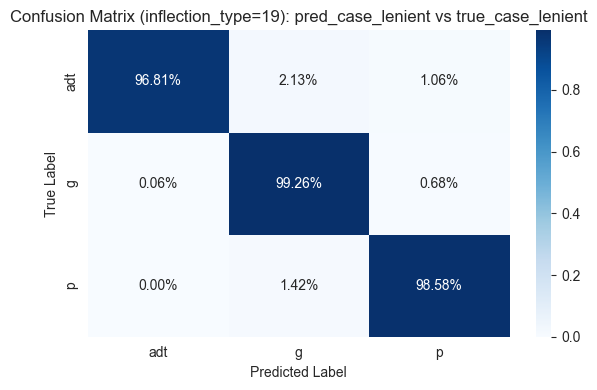

In [19]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

<a id='tulemused_homonyms_50_test'></a>


### Results BertMorphTaggerHomonym50 testset


In [20]:
# Define model to use for annotation
model_path = "../models/NER_mudel_v2_homonym_50/"
model_name = "BertMorphTaggerV2Homonym50_testset"
df_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Bert_morph_V2_homonym_50.csv"
)
df_test_output_csv_path = str(
    HOMONYMS_DIRS["annotations"]
    / "homonyms_annotations_test_Bert_morph_V2_homonym_50.csv"
)

In [21]:
# Load results dataframe
results_df = pd.read_csv(
    df_test_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

BertMorphTaggerV2Homonym50_testset results:
Overall results
Accuracy:  97.91%
Precision: 97.95%
Recall:    97.91%
F1-score:  97.91%

BertMorphTaggerV2Homonym50_testset results (lenient):
Overall results
Accuracy:  97.91%
Precision: 97.95%
Recall:    97.91%
F1-score:  97.91%

BertMorphTaggerV2Homonym50_testset results (lenient, excluding 'other'):
Overall results
Accuracy:  97.91%
Precision: 97.95%
Recall:    97.91%
F1-score:  97.91%

Number of "other" cases: 0 out of 3643 (0.00%)


In [22]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2Homonym50_testset classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.95      0.93      0.94        41
        sg g       0.98      0.99      0.99      2056
        sg n       0.99      0.96      0.98      1122
        sg p       0.94      0.97      0.95       424

    accuracy                           0.98      3643
   macro avg       0.97      0.96      0.96      3643
weighted avg       0.98      0.98      0.98      3643



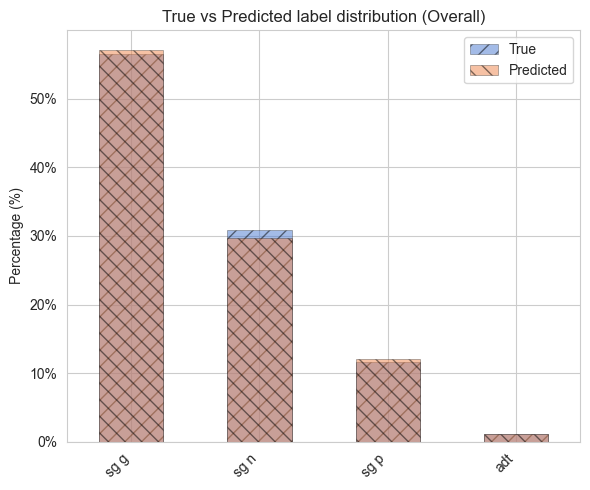

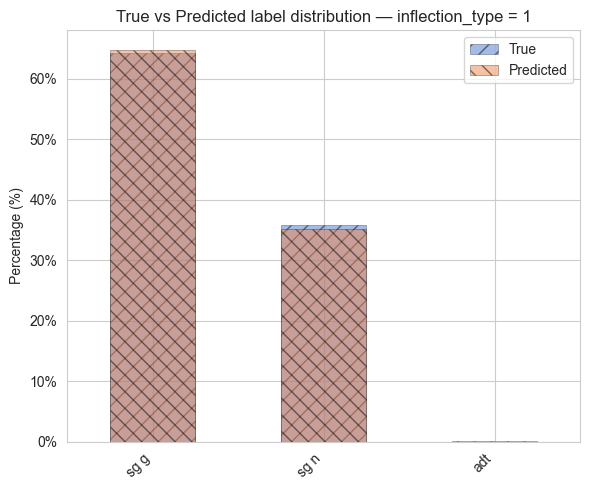

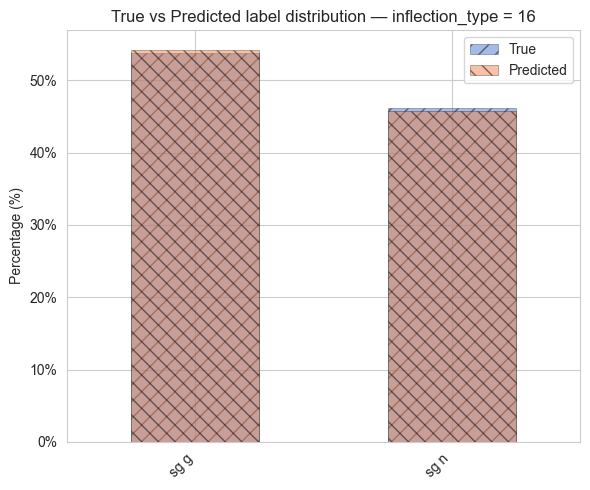

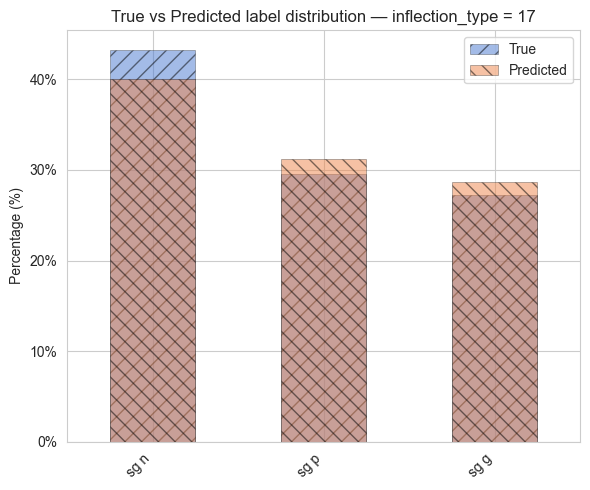

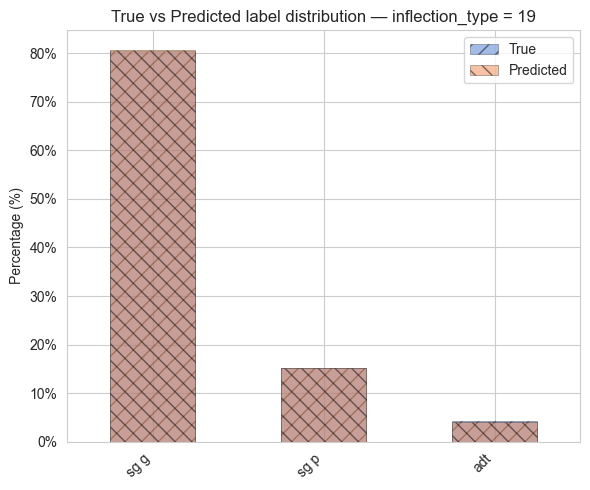

In [23]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

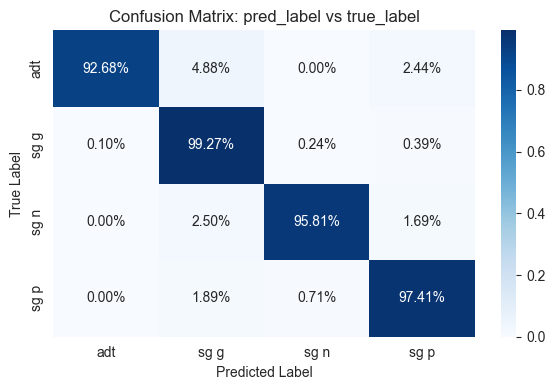

In [24]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

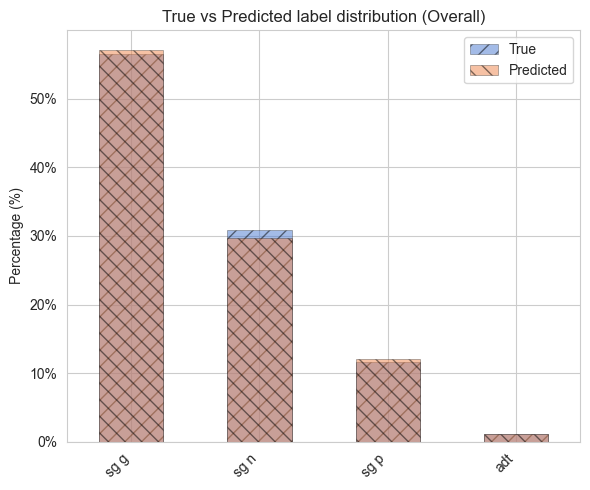

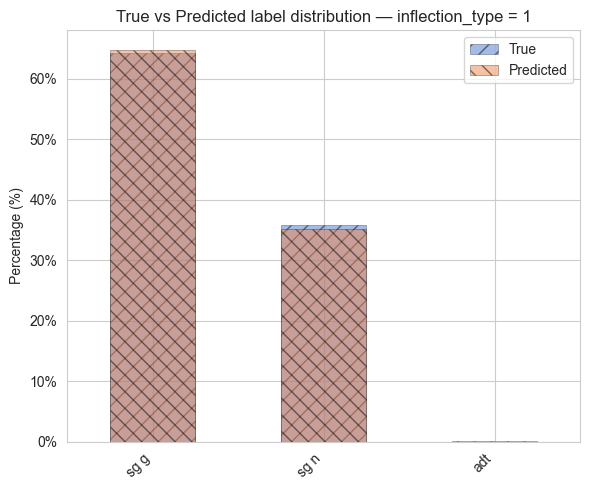

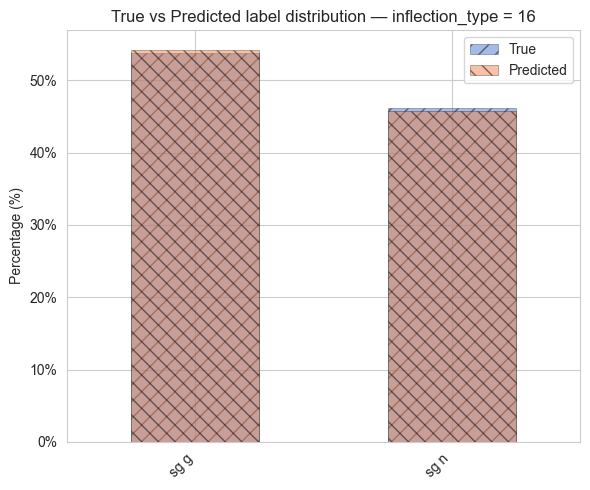

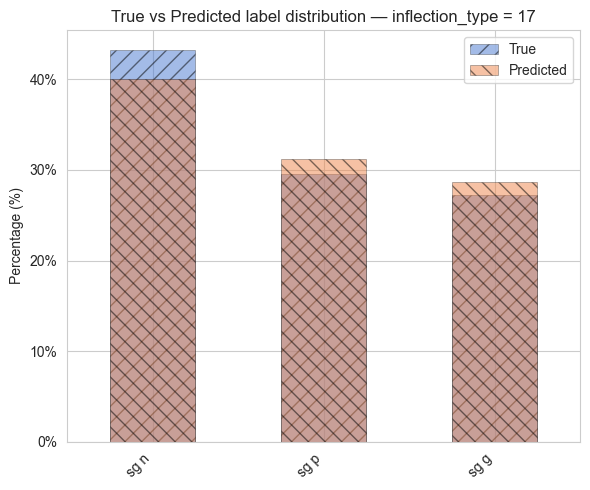

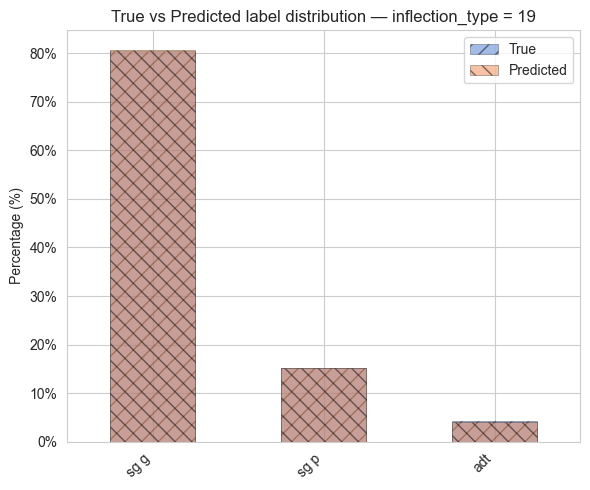

In [25]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

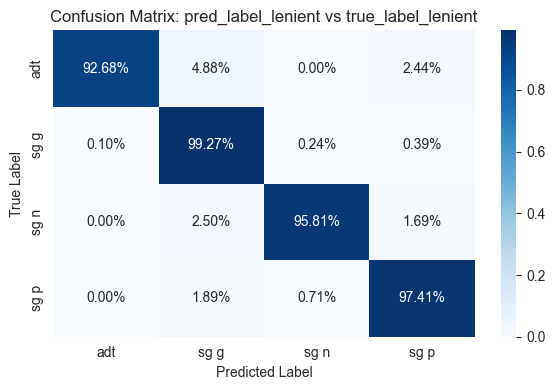

In [26]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

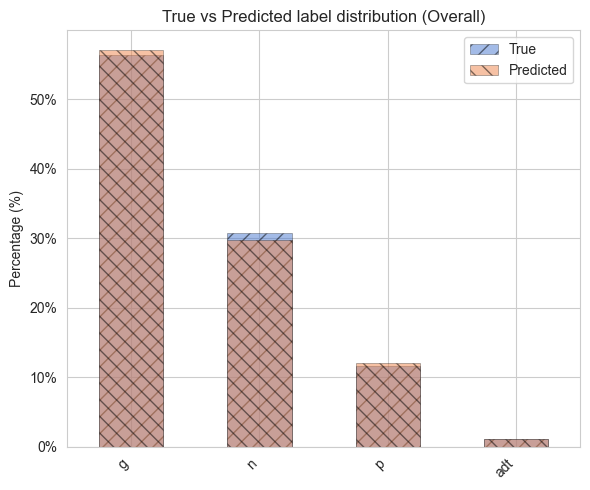

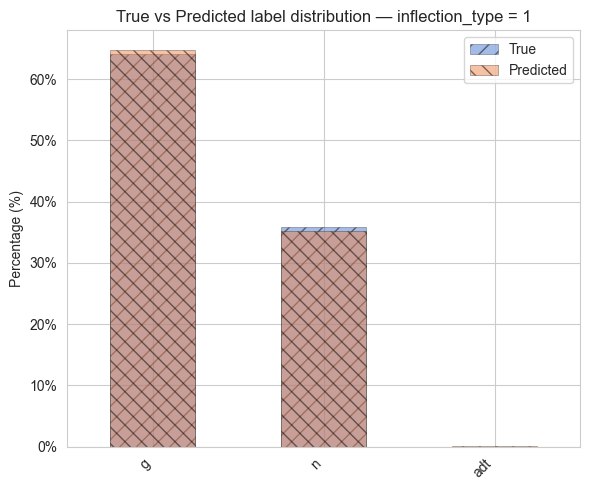

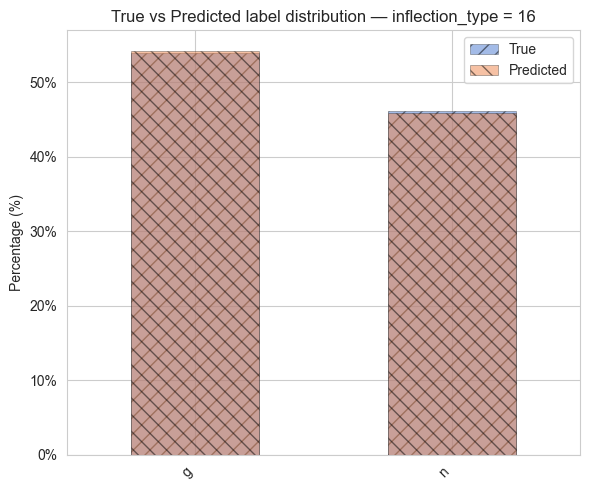

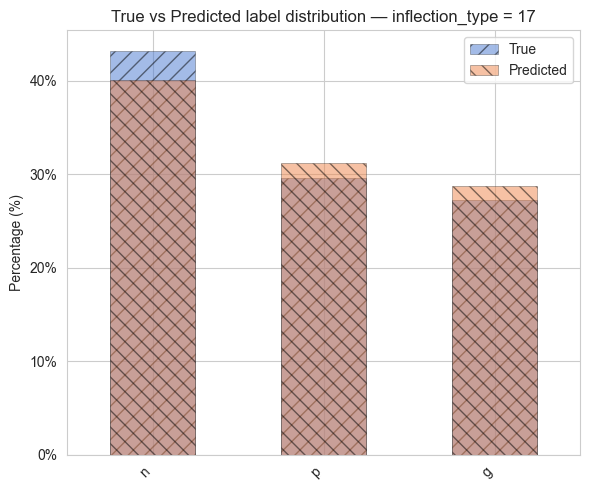

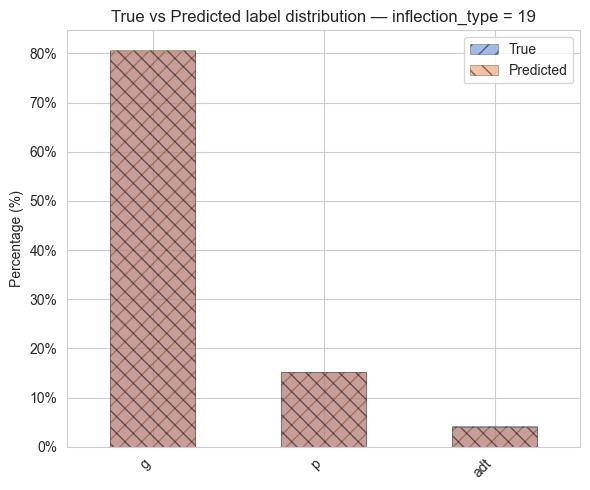

In [27]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

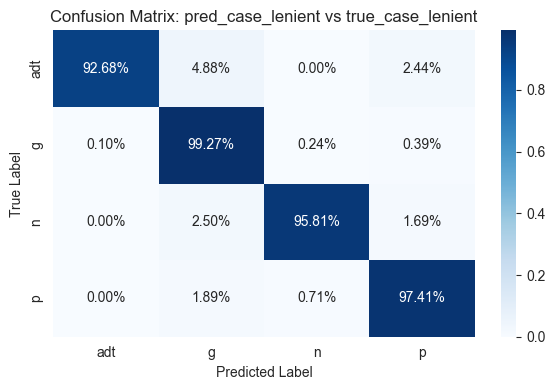

In [28]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

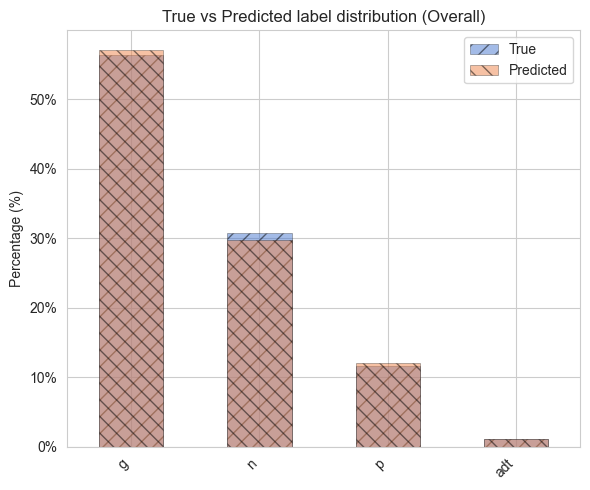

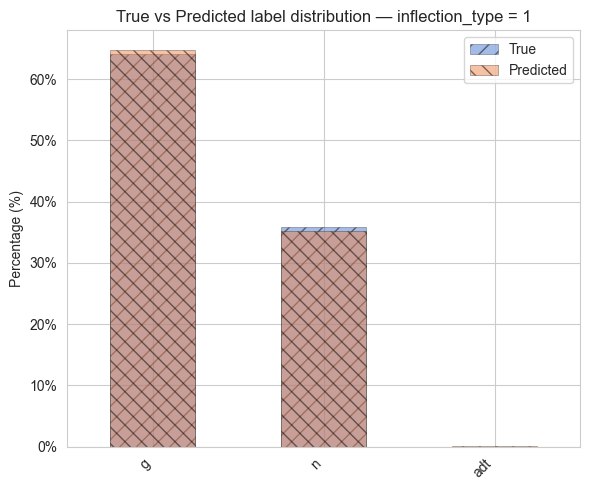

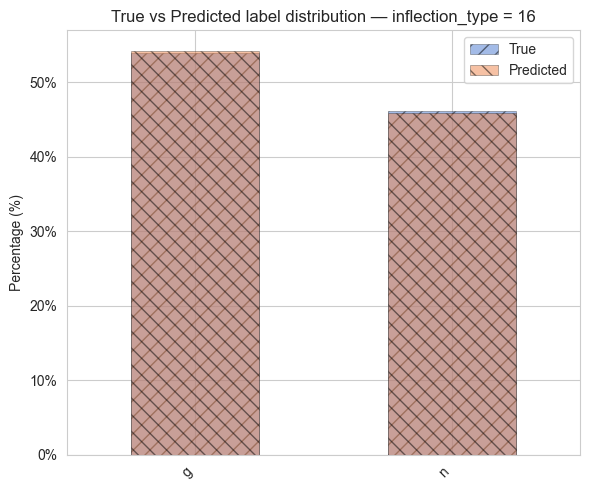

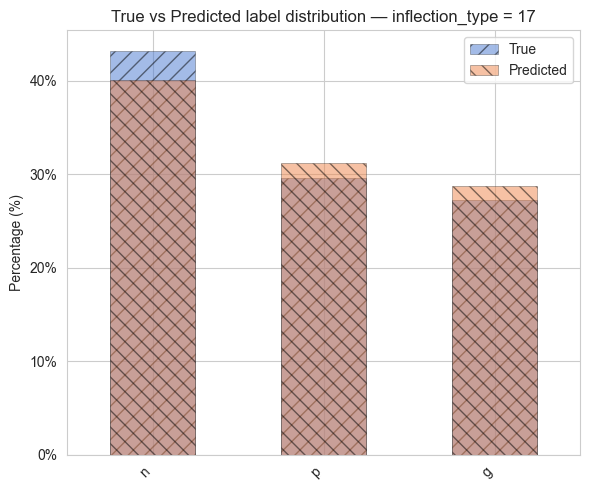

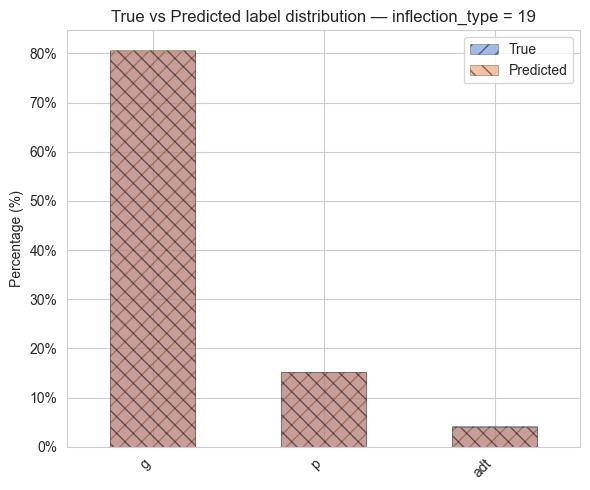

In [29]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

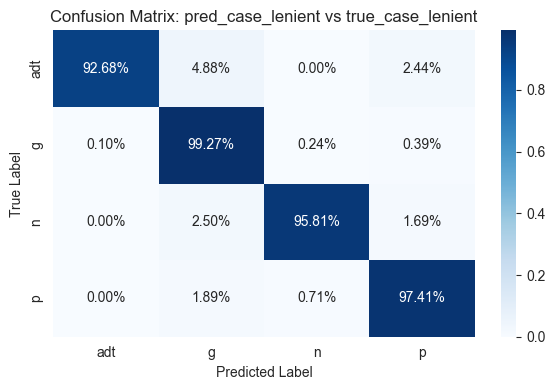

In [30]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [31]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2Homonym50_testset results per inflection type:
inflection_type=1
Accuracy:  98.52%
Precision: 98.63%
Recall:    98.52%
F1-score:  98.57%
inflection_type=16
Accuracy:  99.65%
Precision: 99.66%
Recall:    99.65%
F1-score:  99.65%
inflection_type=17
Accuracy:  94.49%
Precision: 94.71%
Recall:    94.49%
F1-score:  94.50%
inflection_type=19
Accuracy:  99.16%
Precision: 99.16%
Recall:    99.16%
F1-score:  99.16%


In [32]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2Homonym50_testset classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
        sg g       0.98      0.99      0.99       562
        sg n       0.99      0.97      0.98       314

    accuracy                           0.99       876
   macro avg       0.66      0.65      0.66       876
weighted avg       0.99      0.99      0.99       876

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

        sg g       0.99      1.00      1.00       467
        sg n       1.00      0.99      1.00       400

    accuracy                           1.00       867
   macro avg       1.00      1.00      1.00       867
weighted avg       1.00      1.00      1.00       867

inflection_type=17 - Classification Report
              precision    recall  f1-score   support

        sg g       0.92      0

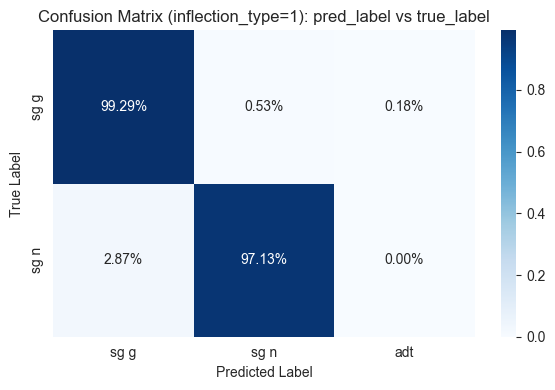

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.11              True              0
Sum of true labels count: 876


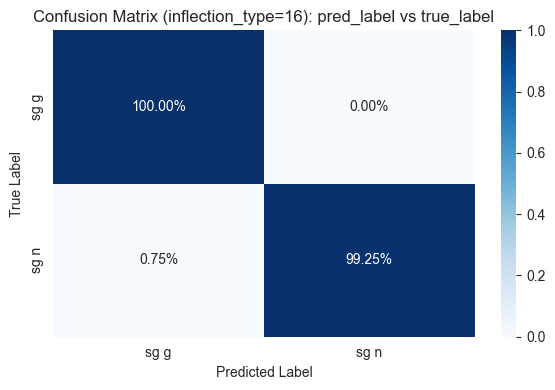

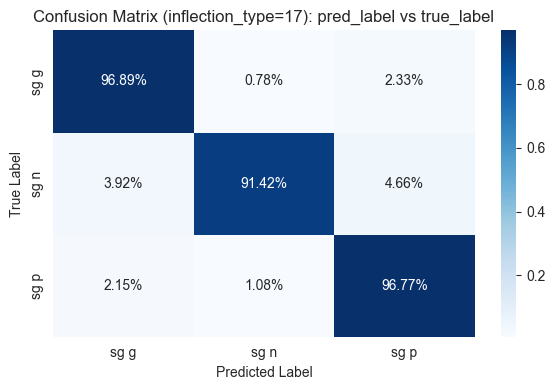

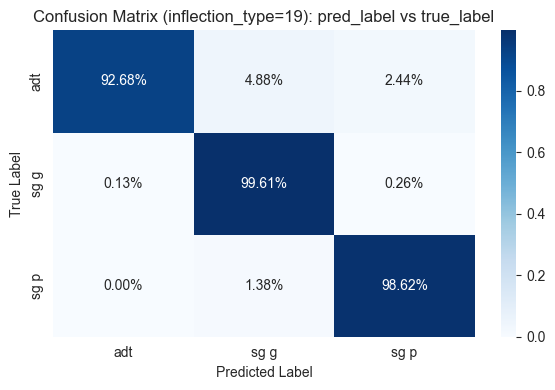

In [33]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

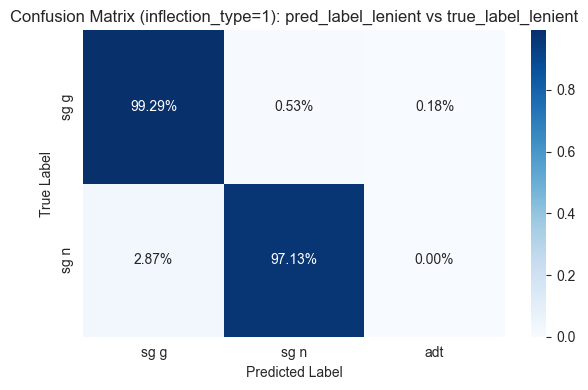

Confusion Matrix (inflection_type=1): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.11              True              0
Sum of true labels count: 876


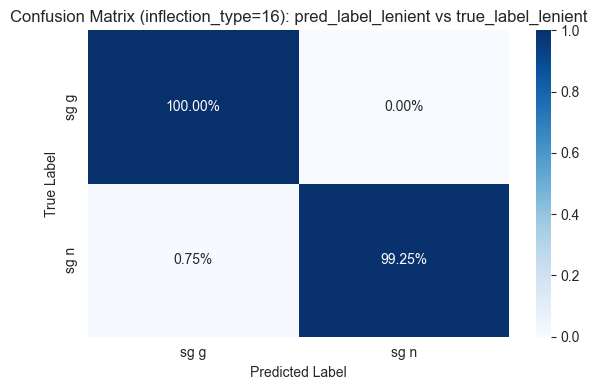

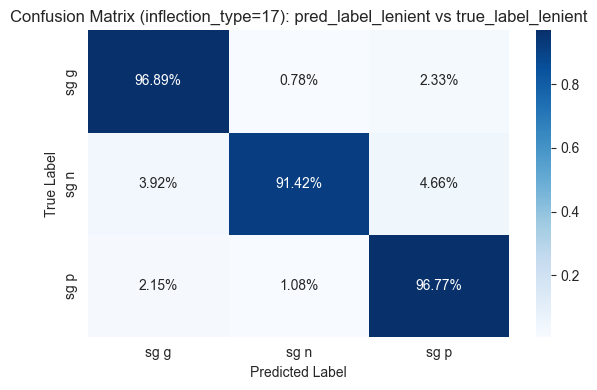

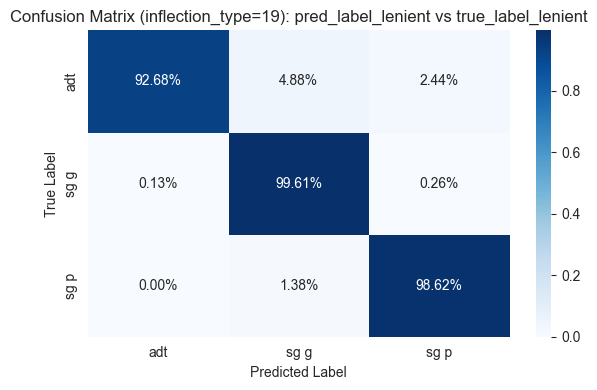

In [34]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

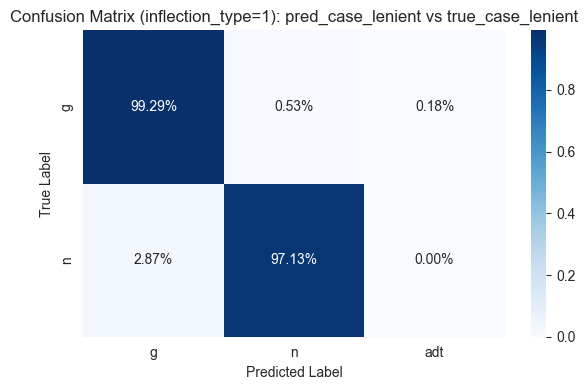

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.11              True              0
Sum of true labels count: 876


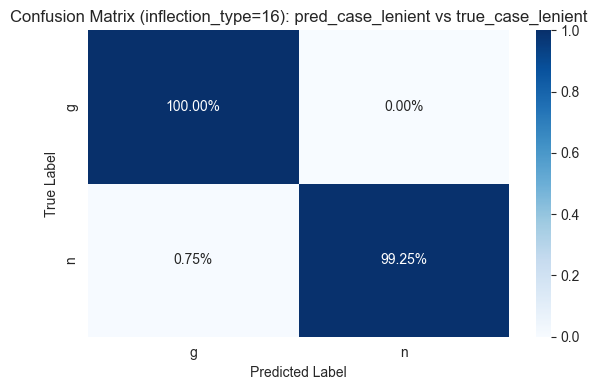

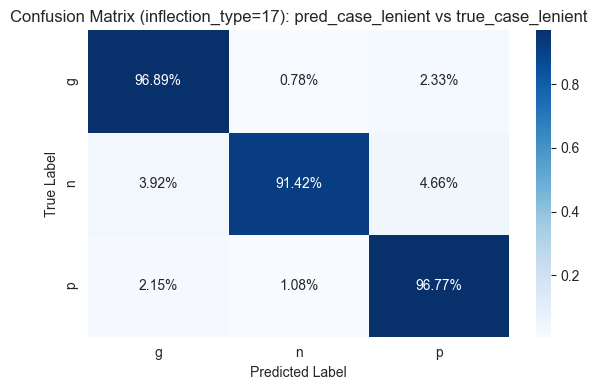

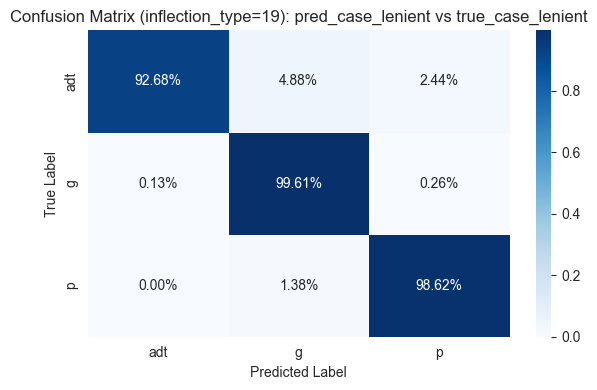

In [35]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

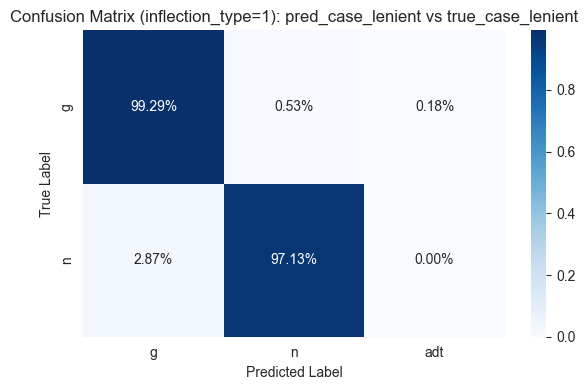

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.11              True              0
Sum of true labels count: 876


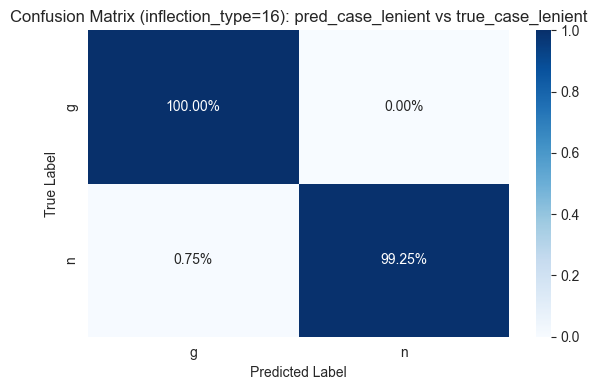

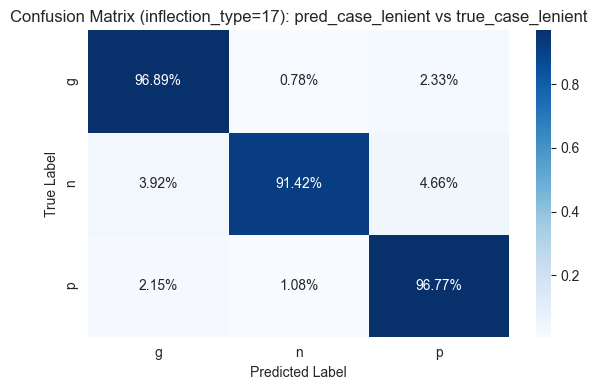

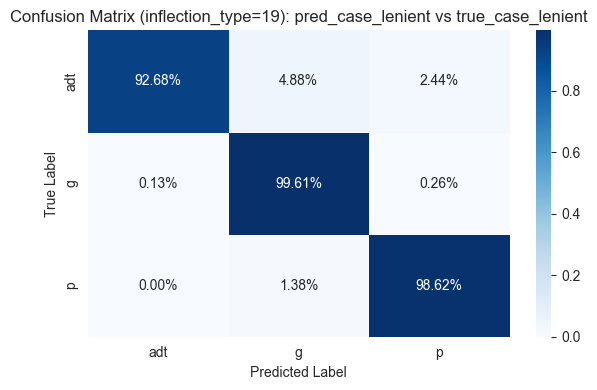

In [36]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)